<a href="https://colab.research.google.com/github/engcriscunha/Machine-Learning---Bootcamp-Avanti/blob/main/desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **DESAFIO – MACHINE LEARNING – AVANTI ATLÂNTICO**

DESAFIO PROPOSTO PELO DOCENTE RENE CALIXTO:

“A seguir, apresento algumas imagens contendo problemas de Visão Computacional que podem ser discutidos nas próximas aulas síncronas. O objetivo é analisar cada cenário e propor possíveis soluções, descrevendo as etapas necessárias para desenvolver um sistema capaz de resolver o problema. É provável que, em processos seletivos para vagas na área de Visão Computacional, seja solicitado que você analise um problema semelhante e explique como o resolveria, incluindo aspectos como: Definição do objetivo do sistema; Coleta e preparação dos dados (dataset); Estratégias de anotação dos dados; Pré-processamento das imagens; Escolha do modelo ou abordagem de IA; Processo de treinamento e validação; Métricas de avaliação; Durante as discussões, o foco não será apenas identificar qual técnica utilizar, mas também justificar as decisões tomadas em cada etapa do desenvolvimento da solução.”


1)	Imagem 01 – objetivo: Contagem de objetos



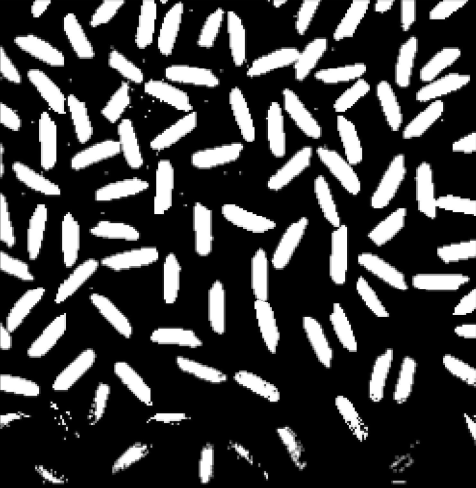


Para essa imagem, a técnica de Processamento Digital de Imagens (PDI) é a mais adequada, pois o cenário apresenta fundo uniforme, alto contraste e objetos com formato semelhante. Nessas condições, operações clássicas como filtro gaussiano, limiarização, operações morfológicas e detecção de contornos são suficientes para obter uma contagem precisa, dispensando o treinamento de modelos de Deep Learning. Caso as imagens apresentassem fundos complexos, variações de iluminação ou objetos de diferentes classes, uma abordagem baseada em CNNs (como YOLO ou Mask R-CNN) seria mais apropriada.

#### Pipeline do Sistema de Contagem de Objetos

```text
                Imagem Original
                       │
                       ▼
             Leitura da Imagem
               (OpenCV - cv2.imread)
                       │
                       ▼
        Conversão para Escala de Cinza
          (cv2.cvtColor - COLOR_BGR2GRAY)
                       │
                       ▼
         Remoção de Ruídos (Filtro Gaussiano)
            (cv2.GaussianBlur)
                       │
                       ▼
               Binarização da Imagem
              (cv2.threshold)
                       │
                       ▼
           Operações Morfológicas
      (Abertura e Fechamento - MorphologyEx)
                       │
                       ▼
      Separação de Objetos Sobrepostos
   (Distance Transform + Watershed - opcional)
                       │
                       ▼
         Detecção dos Objetos
 (findContours ou Connected Components)
                       │
                       ▼
          Contagem dos Objetos
                       │
                       ▼
      Exibição da Quantidade Encontrada
         e Visualização dos Contornos
```

In [ ]:
# Importação das bibliotecas

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Importação da imagem que será avaliada

from google.colab import files

uploaded = files.upload()

Saving objetos.png to objetos.png


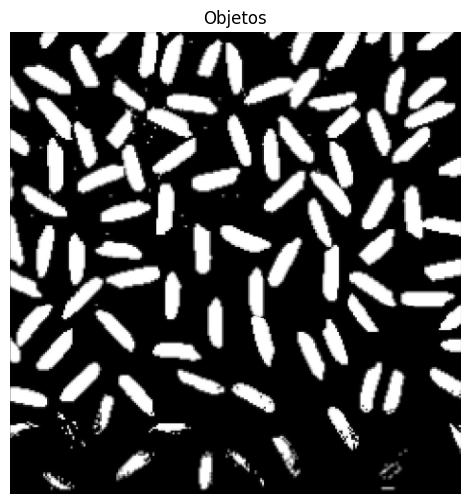

In [ ]:
# Leitura da imagem
# O OpenCV utiliza o padrão BGR, por isso a conversão para RGB é necessária apenas para exibição correta no Matplotlib.

imagem = cv2.imread("objetos.png")

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
plt.title("Objetos")
plt.axis("off")
plt.show()

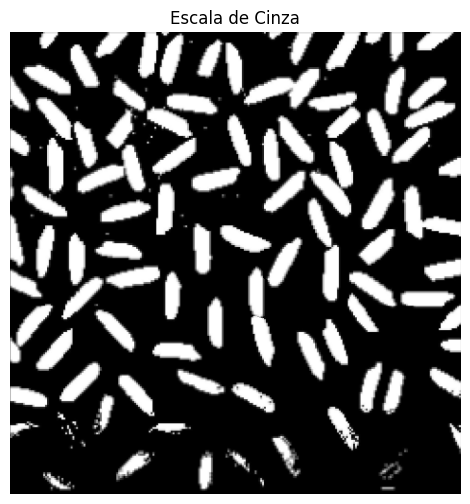

In [ ]:
# Conversão da imagem para escala de cinza

cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(cinza, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")
plt.show()

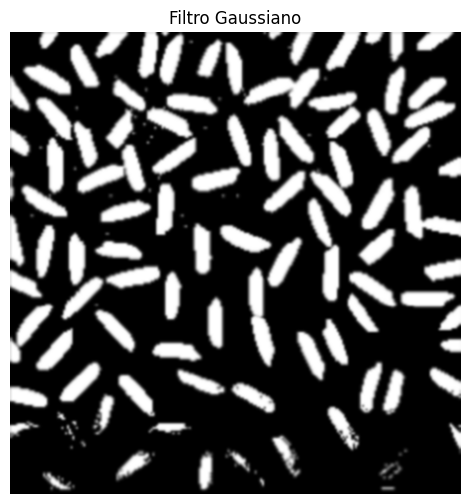

In [ ]:
# Remoção de ruídos com Filtro Gaussiano

gauss = cv2.GaussianBlur(cinza, (5,5), 0)
# (5,5) é o tamanho da máscara, 0 indica que o OpenCV calculará automaticamente o valor de sigma.

plt.figure(figsize=(6,6))
plt.imshow(gauss, cmap="gray")
plt.title("Filtro Gaussiano")
plt.axis("off")
plt.show()

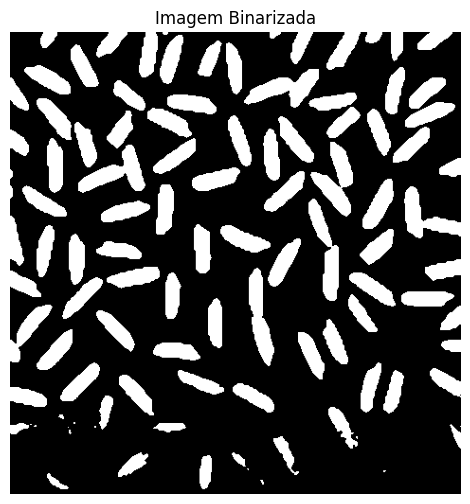

In [ ]:
# Binarização (Threshold)
# Após essa etapa:
# pixels acima de 127 tornam-se 255 (brancos) e pixels abaixo tornam-se 0 (pretos). Agora existe uma separação clara entre objeto e fundo.

_, binaria = cv2.threshold(
    gauss,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(binaria, cmap="gray")
plt.title("Imagem Binarizada")
plt.axis("off")
plt.show()

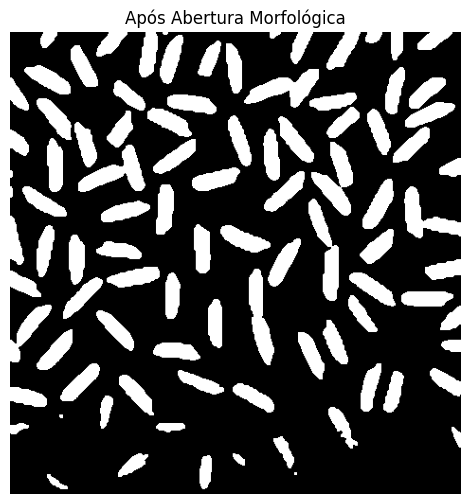

In [ ]:
# Remoção de pequenos ruídos (Abertura Morfológica)

# A operação de abertura consiste em: erosão, seguida de dilatação.
# O que acontece na erosão?
# A erosão diminui os objetos brancos.Ela remove pequenos pontos e pequenas saliências.
# Depois da erosão, ocorre a dilatação.
# Ela aumenta novamente o tamanho do objeto.
# Assim, o objeto principal volta aproximadamente ao tamanho original, mas os pequenos ruídos que desapareceram na erosão não retornam.

kernel = np.ones((3,3), np.uint8)
# np.ones() → cria uma matriz preenchida com o valor 1;
# (3,3) → a matriz terá 3 linhas e 3 colunas;
# np.uint8 → cada elemento será um inteiro sem sinal de 8 bits (valores entre 0 e 255), que é o formato normalmente utilizado para imagens.

abertura = cv2.morphologyEx(
    binaria,
    cv2.MORPH_OPEN,
    kernel
)
# cv2.morphologyEx()
# Essa função aplica operações morfológicas em imagens binárias ou em escala de cinza.
# Sua sintaxe é: cv2.morphologyEx(imagem, operacao, kernel)
# Quanto maior o kernel:maior remoção de ruídos; maior o risco de alterar o formato dos objetos.

plt.figure(figsize=(6,6))
plt.imshow(abertura, cmap="gray")
plt.title("Após Abertura Morfológica")
plt.axis("off")
plt.show()



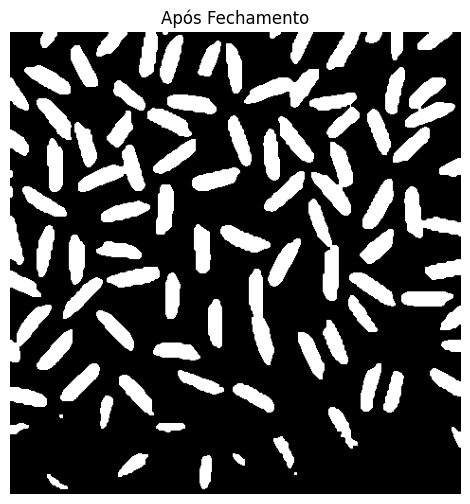

In [ ]:
# Fechamento Morfológico
# O fechamento morfológico elimina pequenos buracos existentes dentro dos objetos.

fechamento = cv2.morphologyEx(
    abertura,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(fechamento, cmap="gray")
plt.title("Após Fechamento")
plt.axis("off")
plt.show()

In [ ]:
# Encontrar contornos
# A função findContours() procura os contornos (bordas externas) dos objetos presentes em uma imagem binária.

contornos, _ = cv2.findContours(
    fechamento,
    cv2.RETR_EXTERNAL, # Recupera apenas os contornos externos.
    cv2.CHAIN_APPROX_SIMPLE # Armazena apenas os pontos necessários para representar o contorno. Em vez de guardar todos os pixels da borda, ele guarda apenas os vértices principais.
)

In [ ]:
# Contagem dos objetos

quantidade = len(contornos)

print(f"Foram encontrados {quantidade} objetos na imagem.")

Foram encontrados 93 objetos na imagem.


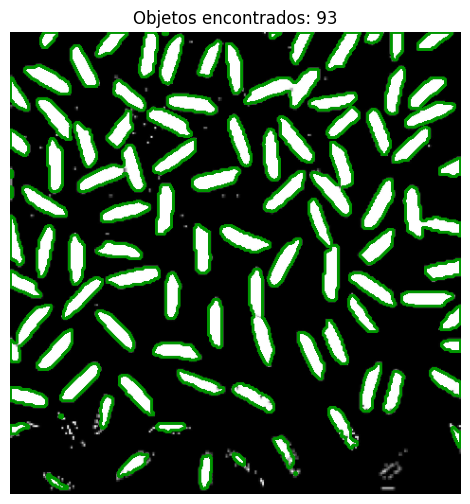

In [ ]:
# Desenhar os contornos

resultado = imagem.copy()

cv2.drawContours(
    resultado,
    contornos,
    -1, # Indica quais contornos serão desenhados, -1 o OpenCV desenha todos os contornos encontrados.
    (0, 150, 0), # cor verde escuro
    2
)
# A função drawContours() desenha os contornos encontrados anteriormente pela função findContours().
# Sua sintaxe é: cv2.drawContours(imagem, contornos, indice, cor, espessura)


plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title(f"Objetos encontrados: {quantidade}")
plt.axis("off")
plt.show()

In [ ]:
# Melhorando a separação de objetos encostados (Watershed)

# Na imagem fornecida existem alguns objetos muito próximos. Nesses casos, o método de contornos pode interpretar dois objetos encostados como um único objeto.

dist = cv2.distanceTransform(fechamento, cv2.DIST_L2, 5)

# A função distanceTransform() calcula a distância de cada pixel branco até o pixel preto mais próximo.
# Em outras palavras, ela informa o quão distante um pixel está da borda do objeto.
# DIST_L2 - utiliza a distância Euclidiana. É a distância "em linha reta". É a forma mais utilizada em Visão Computacional.
# 5 é o tamanho da máscara utilizada no cálculo.

_, sure_fg = cv2.threshold(
    dist,
    0.4 * dist.max(), # 0.4 Este é o limiar (threshold), é um valor empírico bastante utilizado.
    255, # É o valor atribuído aos pixels que satisfazem o limiar, eles ficam brancos.
    0 # Equivale a: cv2.THRESH_BINARY ou seja, realiza uma limiarização binária simples.
)

sure_fg = np.uint8(sure_fg)
# sure_fg representa o Foreground Seguro. Região onde temos alta confiança de que pertence ao objeto. Ela contém apenas o centro dos objetos.
# A Transformada da Distância produz uma imagem do tipo: float32. uint8 inteiros entre 0 e 255, exemplo: antes 12.7 agora 12

In [ ]:
# Região de fundo
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(fechamento, kernel, iterations=3)

# Região desconhecida
unknown = cv2.subtract(sure_bg, sure_fg)

# Rotular os objetos
num_labels, markers = cv2.connectedComponents(sure_fg)

# Incrementar os marcadores
markers = markers + 1

# Marcar a região desconhecida com zero
markers[unknown == 255] = 0

In [ ]:
markers = cv2.watershed(imagem, markers)

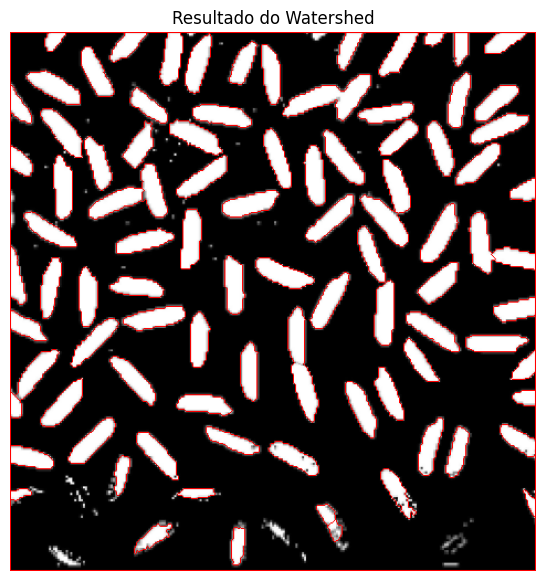

In [ ]:
resultado = imagem.copy()

resultado[markers == -1] = [0, 0, 255]   # Vermelho

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Resultado do Watershed")
plt.axis("off")
plt.show()

In [ ]:
# Contar os rótulos (labels) gerados pelo Watershed.

# Aplicar o Watershed
markers = cv2.watershed(imagem, markers)

# Os valores únicos representam os objetos encontrados
labels = np.unique(markers)

# Remover os rótulos que não representam objetos
#  1 = fundo
objetos = labels[(labels != 1)]

# Contagem dos objetos
quantidade = len(objetos)

print(f"Quantidade de objetos encontrados: {quantidade}")

Quantidade de objetos encontrados: 95


 ### Conclusão:

 Foram encontrados 93 objetos com contornos;

 Após o Watershed foram contabilizados 95 objetos. Porém pode-se observar que alguns objetos sobrepostos ou unidos não foram contabilizados em ambas as técnicas utilizadas.

 O Watershed pode acabar gerando alguns marcadores muito pequenos devido a ruídos ou imperfeições na segmentação. Em aplicações reais, é comum filtrar esses marcadores pela área antes de contá-los. Assim, pequenos fragmentos não são contabilizados como objetos.

2. Imagem caixas



In [1]:
# Importação das bibliotecas

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Importação da imagem que será avaliada

from google.colab import files

uploaded = files.upload()

Saving caixas.png to caixas.png


## Pipeline de Processamento de Imagens

```text
Imagem original
      ↓
Filtro Gaussiano
      ↓
Conversão BGR → HSV
      ↓
Segmentação por cor
      ↓
Abertura Morfológica
      ↓
Fechamento Morfológico
      ↓
Distance Transform
      ↓
Threshold
      ↓
Connected Components
      ↓
Watershed
      ↓
Detecção dos objetos
      ↓
Contagem das caixas

#### Redimensionamento

In [6]:
nome_arquivo = list(uploaded.keys())[0]

imagem = cv2.imread(nome_arquivo)

print("Imagem carregada:", nome_arquivo)
print("Tamanho:", imagem.shape)




Imagem carregada: caixas.png
Tamanho: (643, 477, 3)


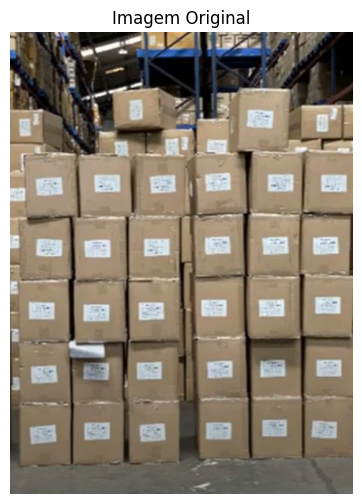

In [7]:
plt.figure(figsize=(6, 6))

plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))

plt.title("Imagem Original")
plt.axis("off")
plt.show()

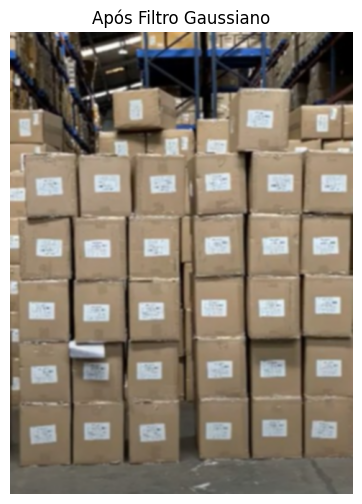

In [10]:
# filtro Gaussiano

# Redução de ruídos
imagem_suave = cv2.GaussianBlur(
    imagem,
    (5, 5),
    0
)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(imagem_suave, cv2.COLOR_BGR2RGB))
plt.title("Após Filtro Gaussiano")
plt.axis("off")
plt.show()

In [11]:
hsv = cv2.cvtColor(imagem, cv2.COLOR_BGR2HSV)

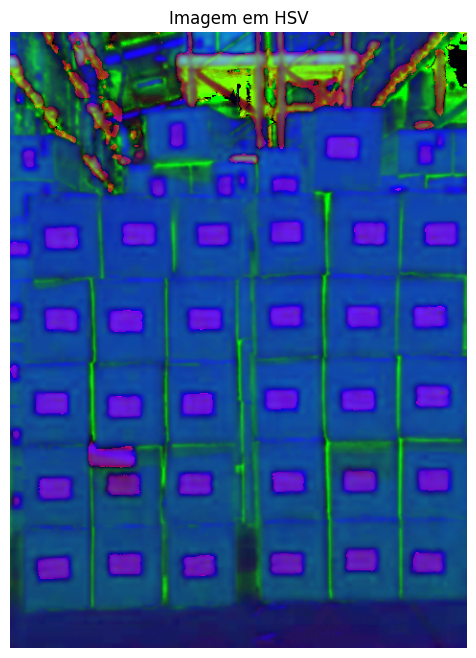

In [12]:
# converter para HSV

hsv = cv2.cvtColor(
    imagem_suave,
    cv2.COLOR_BGR2HSV
)

plt.figure(figsize=(8, 8))
plt.imshow(hsv)
plt.title("Imagem em HSV")
plt.axis("off")
plt.show()

#### Criar uma máscara
Essa etapa provavelmente precisará ser ajustada, porque a iluminação da fotografia não é uniforme.

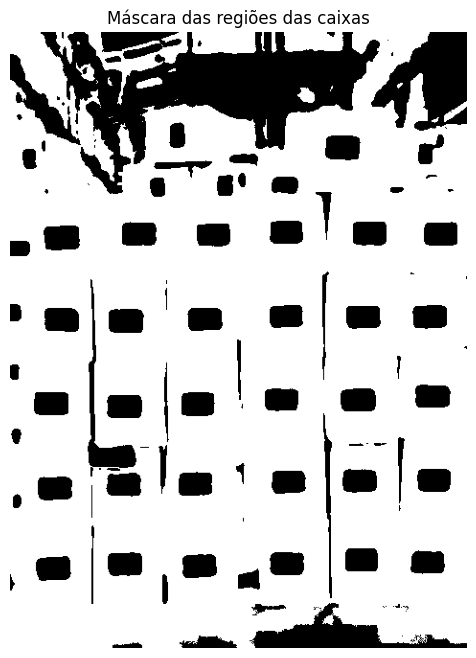

In [13]:
lower = np.array([5, 20, 50])
upper = np.array([30, 255, 255])

mascara = cv2.inRange(
    hsv,
    lower,
    upper
)

plt.figure(figsize=(8, 8))
plt.imshow(mascara, cmap="gray")
plt.title("Máscara das regiões das caixas")
plt.axis("off")
plt.show()

#### Abertura morfológica
remover pequenos ruídos da máscara:

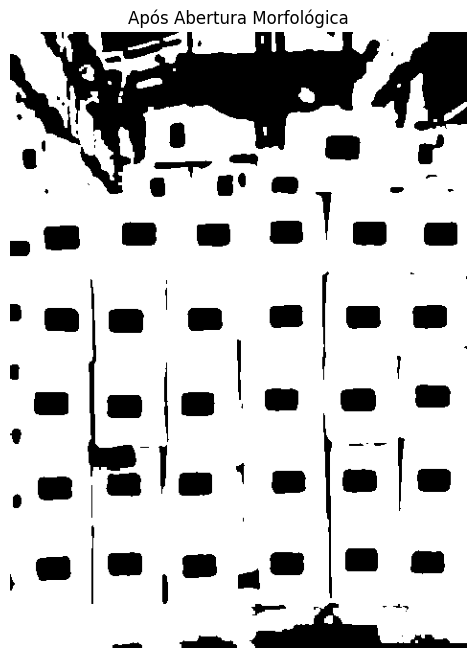

In [14]:
kernel = np.ones((3, 3), np.uint8)

abertura = cv2.morphologyEx(
    mascara,
    cv2.MORPH_OPEN,
    kernel
)

plt.figure(figsize=(8, 8))
plt.imshow(abertura, cmap="gray")
plt.title("Após Abertura Morfológica")
plt.axis("off")
plt.show()

#### Fechamento morfológico
Agora tentamos preencher pequenas falhas dentro das regiões:

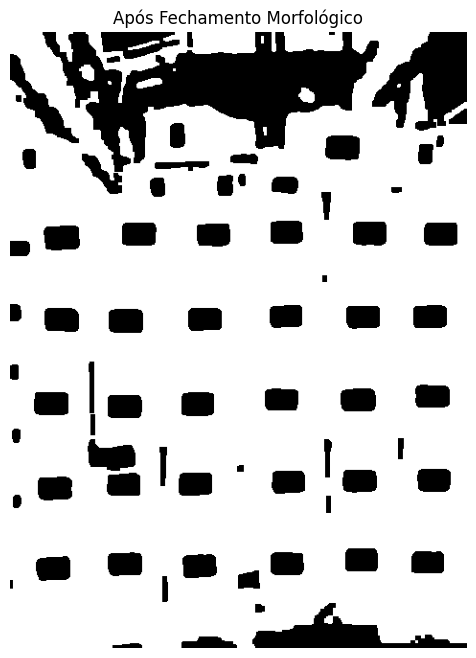

In [15]:
fechamento = cv2.morphologyEx(
    abertura,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

plt.figure(figsize=(8, 8))
plt.imshow(fechamento, cmap="gray")
plt.title("Após Fechamento Morfológico")
plt.axis("off")
plt.show()

#### Encontrar os contornos

In [16]:
contornos, _ = cv2.findContours(
    fechamento,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contornos encontrados:", len(contornos))

Contornos encontrados: 14


#### Filtrar objetos pequenos
eliminar regiões muito pequenas

In [17]:
contornos_validos = []

for contorno in contornos:

    area = cv2.contourArea(contorno)

    if area > 500: #O valor 500 é um limiar inicial. Dependendo do resultado da sua imagem, podemos aumentar ou diminuir.
        contornos_validos.append(contorno)

print("Objetos após filtro:", len(contornos_validos))

Objetos após filtro: 3


#### Visualizar os contornos

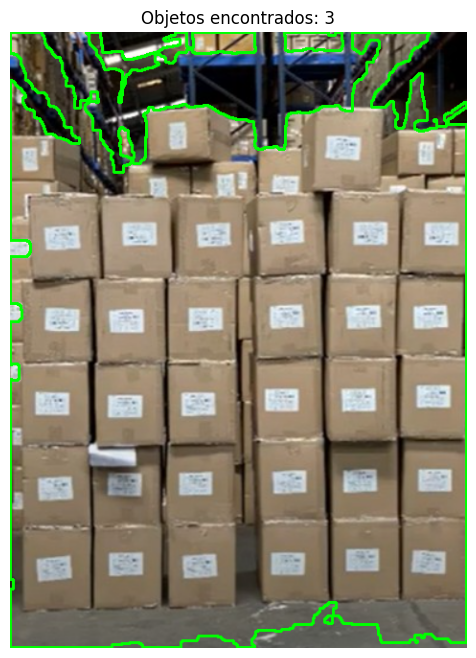

In [18]:
resultado = imagem.copy()

cv2.drawContours(
    resultado,
    contornos_validos,
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(8, 8))
plt.imshow(
    cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)
)

plt.title(
    f"Objetos encontrados: {len(contornos_validos)}"
)

plt.axis("off")
plt.show()

#### Usar Watershed para separar caixas encostadas

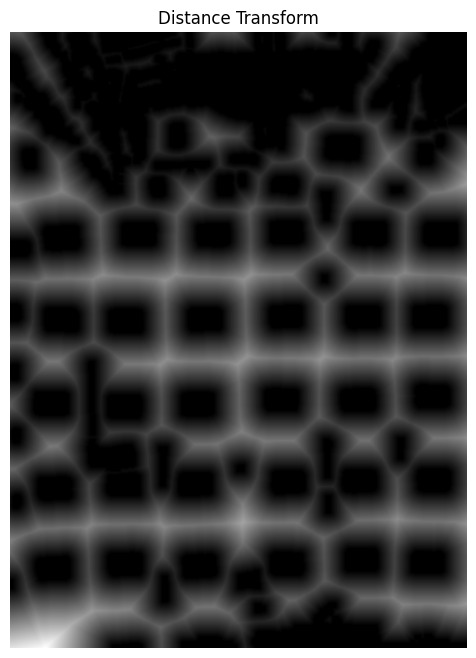

In [19]:
dist = cv2.distanceTransform(
    fechamento,
    cv2.DIST_L2,
    5
)

plt.figure(figsize=(8, 8))
plt.imshow(dist, cmap="gray")
plt.title("Distance Transform")
plt.axis("off")
plt.show()

#### Encontrar o primeiro plano

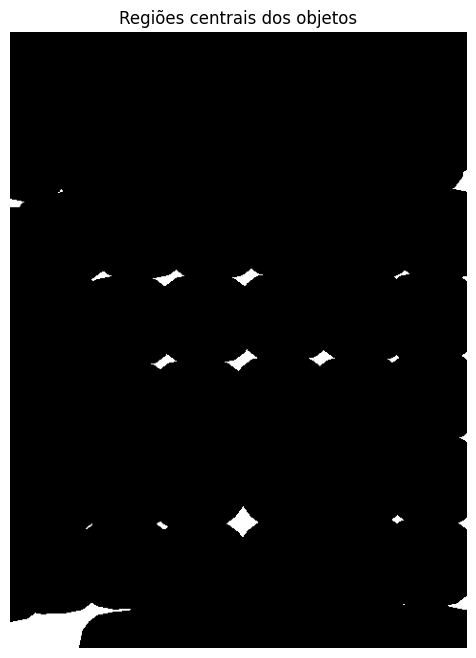

In [71]:
_, sure_fg = cv2.threshold(
    dist,
    0.5* dist.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

plt.figure(figsize=(8, 8))
plt.imshow(sure_fg, cmap="gray")
plt.title("Regiões centrais dos objetos")
plt.axis("off")
plt.show()

#### Encontrar o fundo


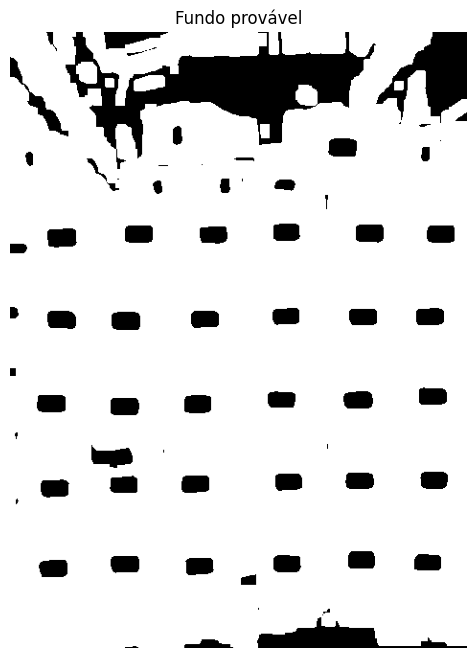

In [72]:
kernel = np.ones((3, 3), np.uint8)

sure_bg = cv2.dilate(
    fechamento,
    kernel,
    iterations=3
)

plt.figure(figsize=(8, 8))
plt.imshow(sure_bg, cmap="gray")
plt.title("Fundo provável")
plt.axis("off")
plt.show()

#### Encontrar regiões desconhecidas

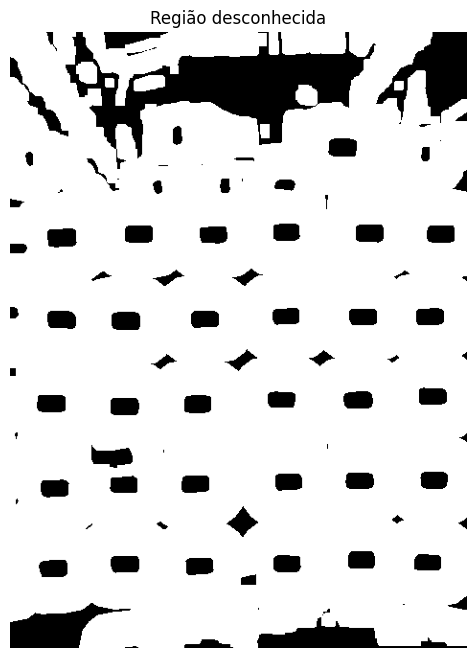

In [73]:
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

plt.figure(figsize=(8, 8))
plt.imshow(unknown, cmap="gray")
plt.title("Região desconhecida")
plt.axis("off")
plt.show()

#### Criar os marcadores

In [74]:
num_labels, markers = cv2.connectedComponents(
    sure_fg
)

print("Marcadores encontrados:", num_labels)

Marcadores encontrados: 23


In [75]:
markers = markers + 1

In [76]:
markers[unknown == 255] = 0

#### Aplicar Watershed

In [77]:
markers = cv2.watershed(
    imagem.copy(),
    markers
)

In [78]:
markers == -1

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True, False, False, ..., False, False,  True],
       [ True, False, False, ..., False, False,  True],
       ...,
       [ True, False, False, ..., False, False,  True],
       [ True, False, False, ..., False, False,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

#### Visualizar o resultado

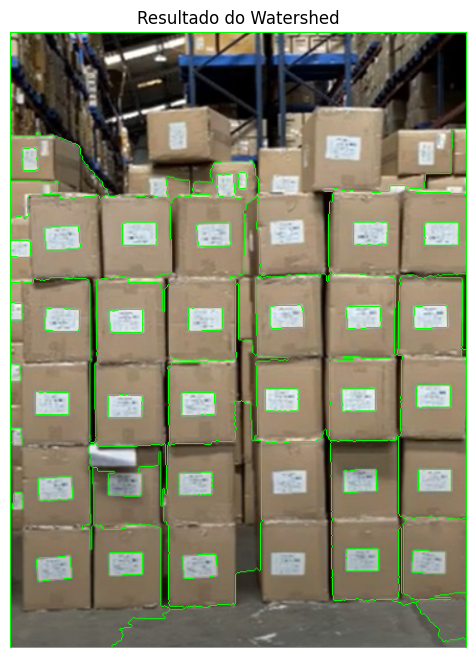

In [79]:
resultado_watershed = imagem.copy()

resultado_watershed[markers == -1] = [0, 255, 0]

plt.figure(figsize=(8, 8))

plt.imshow(
    cv2.cvtColor(
        resultado_watershed,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Resultado do Watershed")
plt.axis("off")
plt.show()

# As linhas verdes representam as fronteiras encontradas pelo Watershed.

#### Contar os objetos

In [80]:
labels_unicos = np.unique(markers)

objetos = labels_unicos[
    (labels_unicos > 1)
]

quantidade = len(objetos)

print("Quantidade de objetos encontrados:", quantidade)

Quantidade de objetos encontrados: 22
